# <b>Introdução</b>

O E-Commerce é um mercado que está em forte expansão no Brasil. Impulsionado pelo crescimento de marketplaces e acesso ampliado à internet e redes de entrega, esse mercado tem projeção de faturamento de <b>R$ 259 bilhões</b> em 2026. Apesar da crescente popularidade de lojas digitais, marketplaces como Olist são dependentes na adesão de clientes, e consequentemente, na satisfação de seus consumidores. O tempo de entrega é um dos pontos mais importantes para que lojas digitais consigam manter clientes ativos e conquistar novos compradores. Portanto, a intenção dessa análise é entender o efeito do tempo de entrega de uma compra sobre a avaliação deixada pelo cliente.

### <b>Pergunta norteadora</b>:
O atraso no tempo de entrega impacta diretamente a nota de avaliação deixada
pelo cliente?

<center>
<img src="imagens/logo_olist.png" alt="Olist logo" title="" width=1000 height=500/>
</center>

### Colunas das datasets
A fonte das datasets utilizadas nesse notebook (https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) possui várias tabelas diferentes contendo informações referentes a compras, clientes e vendedores envolvidos nessas compras. Para essa análise somente serão usadas as tabelas "olist_order_reviews_dataset.csv", "olist_orders_dataset.csv", "archive/olist_order_items_dataset.csv" e "archive/olist_products_dataset.csv", visto que essas bases de dados possuem informações relevantes para responder a pergunta norteadora. As colunas dessas tabelas contém informações como: a nota dada por um cliente, o comentário deixado por um cliente, o status de um pedido (entregue, enviado, etc.), a data de entrega estimada e a data de entrega efetiva.

### <b> 1. Importando bibliotecas e carregando bases de dados</b>

In [78]:
import scipy
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

# Path das bases
path_orders = r"archive/olist_orders_dataset.csv"
path_reviews = r"archive/olist_order_reviews_dataset.csv"
path_items = r"archive/olist_order_items_dataset.csv"
path_products = r"archive/olist_products_dataset.csv"

# Carregando tabelas
df_orders = pd.read_csv(path_orders, sep=None, engine='python')
df_reviews = pd.read_csv(path_reviews, sep=None, engine='python')
df_items = pd.read_csv(path_items, sep=None, engine='python')
df_products = pd.read_csv(path_products, sep=None, engine='python')

### <b>2. Tratamento dos dados</b>

In [79]:
# Juntando as tabelas
df = pd.merge(df_orders, df_reviews, how='outer', on='order_id')
df = pd.merge(df, df_items, how="outer", on="order_id")
df = pd.merge(df, df_products, how="outer", on="product_id")
display(df.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,f30149f4a8882a08895b6a242aa0d612,86c180c33f454b35e1596a99da3dddc4,delivered,2018-05-20 18:45:21,2018-05-20 18:58:59,2018-05-21 16:09:00,2018-06-06 22:11:56,2018-06-20 00:00:00,91845d1f2ee1fdb677c769fad86f2109,5.0,...,101.65,18.59,perfumaria,53.0,596.0,6.0,300.0,20.0,16.0,16.0
1,f5eda0ded77c1293b04c953138c8331d,68f2b37558e27791155db34bcded5ac0,delivered,2017-12-12 19:20:28,2017-12-12 19:32:19,2017-12-20 20:12:42,2017-12-23 17:11:51,2018-01-05 00:00:00,e5636189f943b2589b37f715a3bcae96,4.0,...,129.90,13.93,automotivo,56.0,752.0,4.0,1225.0,55.0,10.0,26.0
2,0bf736fd0fd5169d60de3699fcbcf986,6cd217b674e22cf568f6a2cf6060fd07,delivered,2017-12-21 16:21:47,2017-12-22 17:31:27,2018-01-02 22:27:47,2018-01-06 15:03:41,2018-01-16 00:00:00,32247878e34bd6e8d7dbf7b31a4ae0b0,1.0,...,229.00,13.10,cama_mesa_banho,50.0,266.0,2.0,300.0,45.0,15.0,35.0
3,3aba44d8e554ab4bb8c09f6f78032ca8,82b838f513e00463174cc7cae7e76c1f,delivered,2018-08-10 13:24:35,2018-08-10 13:35:21,2018-08-13 14:43:00,2018-08-17 21:33:40,2018-08-27 00:00:00,40f2e7bbfda859ba75411743546849b0,5.0,...,58.90,19.60,utilidades_domesticas,25.0,364.0,3.0,550.0,19.0,24.0,12.0
4,6f0dfb5b5398b271cc6bbd9ee263530e,8517e7c86998bf39a540087da6f115d9,delivered,2018-08-01 22:00:33,2018-08-01 22:15:19,2018-08-02 14:20:00,2018-08-07 17:38:52,2018-08-24 00:00:00,14303ce09673466b69c4354628aa5a84,5.0,...,58.90,19.60,utilidades_domesticas,25.0,364.0,3.0,550.0,19.0,24.0,12.0


In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114092 entries, 0 to 114091
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114092 non-null  str    
 1   customer_id                    114092 non-null  str    
 2   order_status                   114092 non-null  str    
 3   order_purchase_timestamp       114092 non-null  str    
 4   order_approved_at              113930 non-null  str    
 5   order_delivered_carrier_date   112112 non-null  str    
 6   order_delivered_customer_date  110839 non-null  str    
 7   order_estimated_delivery_date  114092 non-null  str    
 8   review_id                      113131 non-null  str    
 9   review_score                   113131 non-null  float64
 10  review_comment_title           13523 non-null   str    
 11  review_comment_message         48166 non-null   str    
 12  review_creation_date           113131 non

In [81]:
# Não queremos que o mesmo pedido apareça duas vezes
df = df[~df.order_id.duplicated()]

# Quantos valores nulos existem por coluna
nulos = pd.DataFrame({
    'nulos': df.isna().sum(),
    '%':  (df.isna().mean() * 100).round(1),
})
display(nulos)

,nulos,%
order_id,0,0.0
customer_id,0,0.0
order_status,0,0.0
order_purchase_timestamp,0,0.0
order_approved_at,160,0.2
order_delivered_carrier_date,1783,1.8
order_delivered_customer_date,2965,3.0
order_estimated_delivery_date,0,0.0
review_id,768,0.8
review_score,768,0.8


In [82]:
print(df.loc[df['order_status'] == 'delivered']['order_delivered_customer_date'].isna().sum())
print(df.loc[df['order_status'] == 'delivered']['review_score'].isna().sum())

8
646


Valores nulos em order_delivered_customer_date podem ser falhas na coleta de dados ou podem indicar que o pedido nunca chegou, então invés de remover valores nulos vamos criar a categoria para determinar atraso somento com pedidos que já foram entregues, e como só existem 8 pedidos que já foram entregues com order_delivered_customer_date, vamos removê-los. Valores nulos na coluna review_score também serão removidos, pois não temos como estimar a nota de um cliente.

In [83]:
# Garantir que as datas serão tratadas como datetime
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"], errors="coerce")
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"], errors="coerce")

# Somente manter as colunas que queremos
columns = df_orders.columns.to_list() + df_reviews.columns.to_list() + ["price", "product_category_name"]
columns = list(dict.fromkeys(columns))
df_delivered = df.loc[df['order_status'] == 'delivered', columns]
df_delivered = df_delivered.dropna(subset=['order_delivered_customer_date', 'review_score']).reset_index()

df_delivered['atraso_num'] = (df_delivered["order_delivered_customer_date"] - df_delivered["order_estimated_delivery_date"]).dt.days
df_delivered["atraso"] = False
df_delivered.loc[df_delivered["atraso_num"] > 0, "atraso"] = True
df_delivered.loc[df_delivered["atraso_num"] < 0, "atraso"] = False

df_delivered["review_score"] = df_delivered["review_score"].apply(lambda x: int(x))
display(df_delivered.head())

,index,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,price,product_category_name,atraso_num,atraso
0,0,f30149f4a8882a08895b6a242aa0d612,86c180c33f454b35e1596a99da3dddc4,delivered,2018-05-20 18:45:21,2018-05-20 18:58:59,2018-05-21 16:09:00,2018-06-06 22:11:56,2018-06-20,91845d1f2ee1fdb677c769fad86f2109,5,NaN,NaN,2018-06-07 00:00:00,2018-06-08 10:59:20,101.65,perfumaria,-14,False
1,1,f5eda0ded77c1293b04c953138c8331d,68f2b37558e27791155db34bcded5ac0,delivered,2017-12-12 19:20:28,2017-12-12 19:32:19,2017-12-20 20:12:42,2017-12-23 17:11:51,2018-01-05,e5636189f943b2589b37f715a3bcae96,4,NaN,NaN,2017-12-24 00:00:00,2017-12-27 13:23:27,129.90,automotivo,-13,False
2,2,0bf736fd0fd5169d60de3699fcbcf986,6cd217b674e22cf568f6a2cf6060fd07,delivered,2017-12-21 16:21:47,2017-12-22 17:31:27,2018-01-02 22:27:47,2018-01-06 15:03:41,2018-01-16,32247878e34bd6e8d7dbf7b31a4ae0b0,1,NaN,Meu produto não foi entregue até o momento!,2018-01-07 00:00:00,2018-01-11 11:03:53,229.00,cama_mesa_banho,-10,False
3,3,3aba44d8e554ab4bb8c09f6f78032ca8,82b838f513e00463174cc7cae7e76c1f,delivered,2018-08-10 13:24:35,2018-08-10 13:35:21,2018-08-13 14:43:00,2018-08-17 21:33:40,2018-08-27,40f2e7bbfda859ba75411743546849b0,5,NaN,"Produto igual ao anunciado, de excelente quali...",2018-08-18 00:00:00,2018-08-22 12:40:29,58.90,utilidades_domesticas,-10,False
4,4,6f0dfb5b5398b271cc6bbd9ee263530e,8517e7c86998bf39a540087da6f115d9,delivered,2018-08-01 22:00:33,2018-08-01 22:15:19,2018-08-02 14:20:00,2018-08-07 17:38:52,2018-08-24,14303ce09673466b69c4354628aa5a84,5,Produto bom,"Produto bom, mas o pegador da tampa é de plást...",2018-08-08 00:00:00,2018-08-08 23:48:48,58.90,utilidades_domesticas,-17,False


Agora separamos os atrasos em faixas de valores para facilitar as análises.

In [84]:
faixas = [-np.inf, -14, -7, -1, 1, 7, 14, np.inf]
labels = ["Mais de 14 dias adiantado", "14 a 7 dias adiantado", 
          "7 a 0 dias adiantados","No prazo", "0 a 7 dias atrasado", "7 a 14 dias atrasado"
          , "Mais de 14 dias atrasado"]
df_delivered['atraso_faixas'] = pd.cut(df_delivered['atraso_num'], bins=faixas, labels=labels, right=False)
df_delivered.head()

,index,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,price,product_category_name,atraso_num,atraso,atraso_faixas
0,0,f30149f4a8882a08895b6a242aa0d612,86c180c33f454b35e1596a99da3dddc4,delivered,2018-05-20 18:45:21,2018-05-20 18:58:59,2018-05-21 16:09:00,2018-06-06 22:11:56,2018-06-20,91845d1f2ee1fdb677c769fad86f2109,5,NaN,NaN,2018-06-07 00:00:00,2018-06-08 10:59:20,101.65,perfumaria,-14,False,14 a 7 dias adiantado
1,1,f5eda0ded77c1293b04c953138c8331d,68f2b37558e27791155db34bcded5ac0,delivered,2017-12-12 19:20:28,2017-12-12 19:32:19,2017-12-20 20:12:42,2017-12-23 17:11:51,2018-01-05,e5636189f943b2589b37f715a3bcae96,4,NaN,NaN,2017-12-24 00:00:00,2017-12-27 13:23:27,129.90,automotivo,-13,False,14 a 7 dias adiantado
2,2,0bf736fd0fd5169d60de3699fcbcf986,6cd217b674e22cf568f6a2cf6060fd07,delivered,2017-12-21 16:21:47,2017-12-22 17:31:27,2018-01-02 22:27:47,2018-01-06 15:03:41,2018-01-16,32247878e34bd6e8d7dbf7b31a4ae0b0,1,NaN,Meu produto não foi entregue até o momento!,2018-01-07 00:00:00,2018-01-11 11:03:53,229.00,cama_mesa_banho,-10,False,14 a 7 dias adiantado
3,3,3aba44d8e554ab4bb8c09f6f78032ca8,82b838f513e00463174cc7cae7e76c1f,delivered,2018-08-10 13:24:35,2018-08-10 13:35:21,2018-08-13 14:43:00,2018-08-17 21:33:40,2018-08-27,40f2e7bbfda859ba75411743546849b0,5,NaN,"Produto igual ao anunciado, de excelente quali...",2018-08-18 00:00:00,2018-08-22 12:40:29,58.90,utilidades_domesticas,-10,False,14 a 7 dias adiantado
4,4,6f0dfb5b5398b271cc6bbd9ee263530e,8517e7c86998bf39a540087da6f115d9,delivered,2018-08-01 22:00:33,2018-08-01 22:15:19,2018-08-02 14:20:00,2018-08-07 17:38:52,2018-08-24,14303ce09673466b69c4354628aa5a84,5,Produto bom,"Produto bom, mas o pegador da tampa é de plást...",2018-08-08 00:00:00,2018-08-08 23:48:48,58.90,utilidades_domesticas,-17,False,Mais de 14 dias adiantado


In [85]:
df_delivered["product_category_name"] = df_delivered["product_category_name"].astype("category")
df_delivered["product_category_name"].cat.categories

Index(['agro_industria_e_comercio', 'alimentos', 'alimentos_bebidas', 'artes',
       'artes_e_artesanato', 'artigos_de_festas', 'artigos_de_natal', 'audio',
       'automotivo', 'bebes', 'bebidas', 'beleza_saude', 'brinquedos',
       'cama_mesa_banho', 'casa_conforto', 'casa_conforto_2',
       'casa_construcao', 'cds_dvds_musicais', 'cine_foto', 'climatizacao',
       'consoles_games', 'construcao_ferramentas_construcao',
       'construcao_ferramentas_ferramentas',
       'construcao_ferramentas_iluminacao', 'construcao_ferramentas_jardim',
       'construcao_ferramentas_seguranca', 'cool_stuff', 'dvds_blu_ray',
       'eletrodomesticos', 'eletrodomesticos_2', 'eletronicos',
       'eletroportateis', 'esporte_lazer', 'fashion_bolsas_e_acessorios',
       'fashion_calcados', 'fashion_esporte', 'fashion_roupa_feminina',
       'fashion_roupa_infanto_juvenil', 'fashion_roupa_masculina',
       'fashion_underwear_e_moda_praia', 'ferramentas_jardim', 'flores',
       'fraldas_higiene', 

Como existem dezenas de categorias, iremos escolher as 10 com mais volume de pedidos para analisar.

In [86]:
# Mudando o nome das categorias
categorias = df_delivered["product_category_name"].value_counts().head(10).index.to_list()
categorias_renamed = ["Cama, mesa, banho", "Beleza e Saúde", "Esportes e Lazer", "Informática",
              "Movéis e decoração", "Utilidades doméstica", "Presentes", "Telefonia",
              "Automotivo", "Brinquedos"]
dict_renaming = {}
for i in range(len(categorias)):
    dict_renaming[categorias[i]] = categorias_renamed[i]
df_delivered["product_category_name"] = df_delivered["product_category_name"].cat.rename_categories(dict_renaming)
print(dict_renaming)

{'cama_mesa_banho': 'Cama, mesa, banho', 'beleza_saude': 'Beleza e Saúde', 'esporte_lazer': 'Esportes e Lazer', 'informatica_acessorios': 'Informática', 'moveis_decoracao': 'Movéis e decoração', 'utilidades_domesticas': 'Utilidades doméstica', 'relogios_presentes': 'Presentes', 'telefonia': 'Telefonia', 'automotivo': 'Automotivo', 'brinquedos': 'Brinquedos'}


### 3. Análise exploratória dos dados

In [87]:
# Média de notas para pedidos atrasodos vs não atrasados
print(f"Não atrasados: {df_delivered.loc[df_delivered['atraso'] == False, 'review_score'].mean():.2f}")
print(f"Atrasados: {df_delivered.loc[df_delivered['atraso'] == True, 'review_score'].mean():.2f}")

Não atrasados: 4.29
Atrasados: 2.27


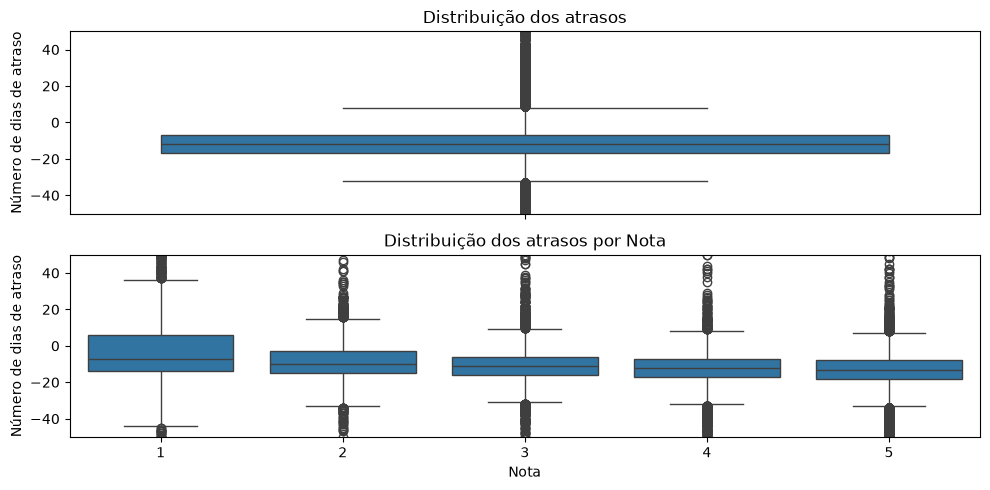

In [88]:
# Entendendo a distribuição de atrasos
plt.figure(figsize=(10,5))

plt.subplot(211)
sns.boxplot(data=df_delivered, y="atraso_num")
plt.title("Distribuição dos atrasos")
plt.ylabel("Número de dias de atraso")
plt.ylim(-50, 50)

plt.subplot(212)
sns.boxplot(data=df_delivered, x="review_score", y="atraso_num")
plt.title("Distribuição dos atrasos por Nota")
plt.xlabel("Nota")
plt.ylabel("Número de dias de atraso")
plt.ylim(-50, 50)
plt.tight_layout()
plt.show()

Podemos ver que os dados estão muito concentrados um pouco antes de 0 dias, portanto não tem como visualizar os dados usando o histograma direito.

In [89]:
# Medidas resumo
display(df_delivered["atraso_num"].describe().to_frame().transpose())

,count,mean,std,min,25%,50%,75%,max
atraso_num,95824.0,-11.91307,10.111737,-147.0,-17.0,-12.0,-7.0,188.0


In [90]:
# Agora as medidas resumo agrupando por review
display(df_delivered.groupby(by="review_score", observed=True)["atraso_num"].describe())

,count,mean,std,min,25%,50%,75%,max
review_score,,,,,,,,
1,9343.0,-4.026544,16.039962,-69.0,-14.0,-7.0,6.0,175.0
2,2923.0,-8.622990,12.692926,-56.0,-15.0,-10.0,-3.0,188.0
3,7908.0,-10.779084,10.373724,-135.0,-16.0,-11.0,-6.0,162.0
4,18893.0,-12.383264,9.060509,-75.0,-17.0,-12.0,-7.0,161.0
5,56757.0,-13.382226,8.152247,-147.0,-18.0,-13.0,-8.0,155.0


In [91]:
# Correlação entre dias de atraso e nota
# Usamos Pearson (relação linear) e Spearman (relação monotônica, mais robusta a outliers
# e mais adequada já que review_score é uma variável ordinal, não contínua)
corr_pearson = df_delivered["atraso_num"].corr(df_delivered["review_score"], method="pearson")
corr_spearman = df_delivered["atraso_num"].corr(df_delivered["review_score"], method="spearman")
print(f"Pearson: {corr_pearson:.4f}")
print(f"Spearman: {corr_spearman:.4f}")

Pearson: -0.2673
Spearman: -0.1763


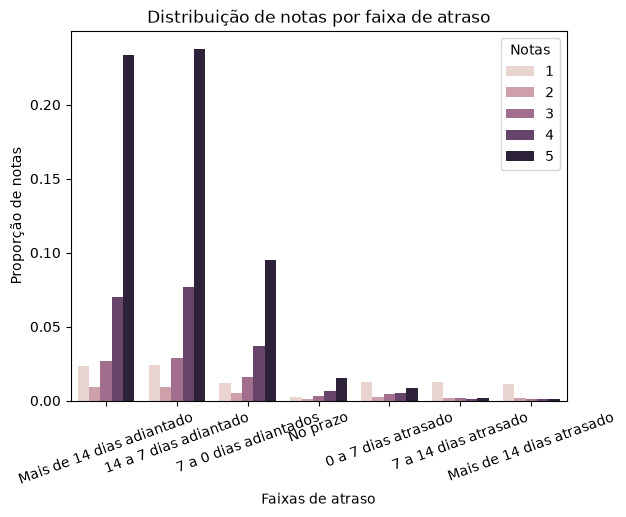

In [99]:
sns.countplot(data=df_delivered, x="atraso_faixas", hue="review_score", stat="proportion")
plt.title("Distribuição de notas por faixa de atraso")
plt.xlabel("Faixas de atraso")
plt.ylabel("Proporção de notas")
plt.xticks(rotation=20)
plt.legend(title="Notas")
plt.show()

Nota-se que a quantidade de reviews 5 a partir da faixa 0 a 7 dias cai consideravelmente. Porém é muito dificil ver como o atraso está distribuido nas faixas mais a direita quando plotados junto com as 3 primeiras faixas.

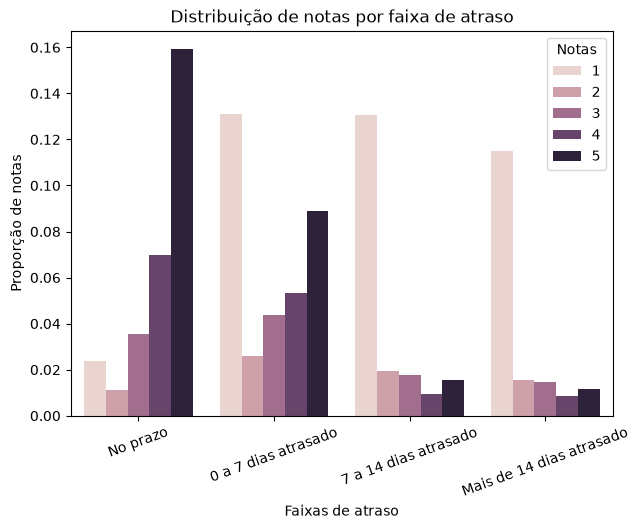

Correlação para o atraso de No prazo: Pearson = -0.0524 | Spearman = -0.0571
Correlação para o atraso de 0 a 7 dias atrasado: Pearson = -0.3960 | Spearman = -0.3958
Correlação para o atraso de 7 a 14 dias atrasado: Pearson = -0.0520 | Spearman = -0.0612
Correlação para o atraso de Mais de 14 dias atrasado: Pearson = 0.2153 | Spearman = 0.0694


In [98]:
df_delivered["atraso_faixas"] = df_delivered["atraso_faixas"].astype("category")
atrasos = df_delivered["atraso_faixas"].cat.categories.to_list()[3:]

df_atrasos = df_delivered.loc[df_delivered["atraso_faixas"].isin(atrasos), :].copy()
df_atrasos["atraso_faixas"] = df_atrasos["atraso_faixas"].cat.remove_unused_categories()

plt.figure(figsize=(7,5))
sns.countplot(data=df_atrasos, x="atraso_faixas", hue="review_score", stat="proportion")
plt.title("Distribuição de notas por faixa de atraso")
plt.xlabel("Faixas de atraso")
plt.ylabel("Proporção de notas")
plt.legend(title="Notas")
plt.xticks(rotation=20)
plt.show()

for categ in df_atrasos["atraso_faixas"].cat.categories.to_list():
    atraso_categ = df_atrasos.loc[df_atrasos["atraso_faixas"] == categ, "atraso_num"]
    nota_categ = df_atrasos.loc[df_atrasos["atraso_faixas"] == categ, "review_score"]
    pearson = atraso_categ.corr(nota_categ, method="pearson")
    spearman = atraso_categ.corr(nota_categ, method="spearman")
    print(f"Correlação para o atraso de {categ}: Pearson = {pearson:.4f} | Spearman = {spearman:.4f}")


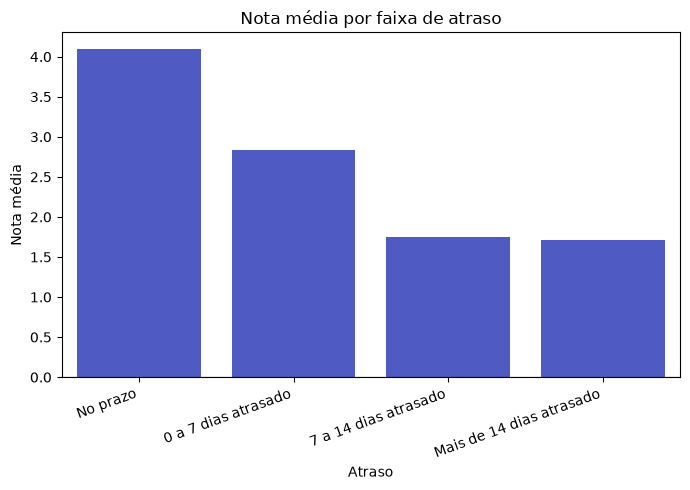

In [ ]:
# Gráfico de nota média por faixa de atraso
notas = {}
for categ in atrasos:
    notas[categ] = df_delivered.loc[df_delivered["atraso_faixas"] == categ, "review_score"].mean()
notas = pd.Series(notas)

plt.figure(figsize=(7, 5))
sns.barplot(x=notas.index, y=notas.values, legend=False, color="#3C4BD6")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=20, ha="right")
plt.xlabel("Atraso")
plt.ylabel("Nota média")
plt.title("Nota média por faixa de atraso")
plt.tight_layout()
plt.show()

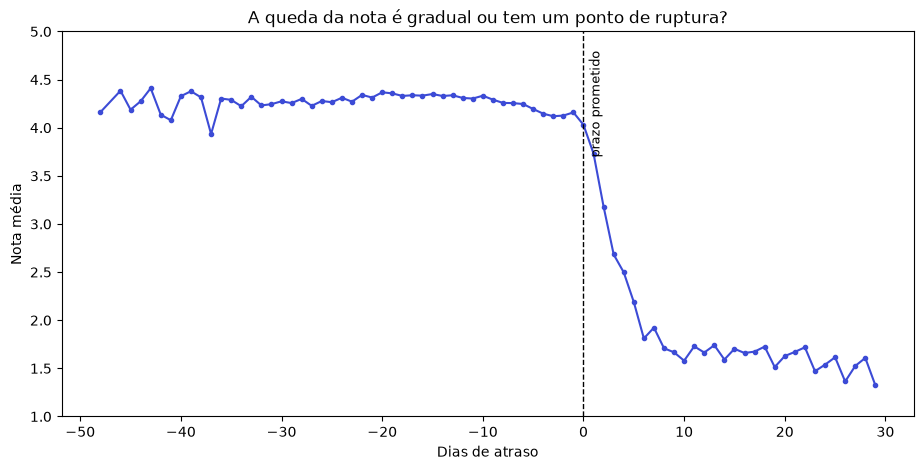

Inclinação média antes do prazo:  -0.0001 ponto/dia
Inclinação média depois do prazo: -0.0457 ponto/dia


In [106]:
min_n = 30           # só plota dias com pelo menos 30 pedidos

resumo = (df_delivered.groupby("atraso_num")
              .agg(nota_media=("review_score", "mean"),
                   pct_nota1=("review_score", lambda s: (s == 1).mean() * 100),
                   n=("review_score", "size"))
              .reset_index())
resumo = resumo.loc[resumo["n"] >= min_n]

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(resumo["atraso_num"], resumo["nota_media"],
         marker="o", markersize=3, color="#3C4BD6", label="Nota média")
ax1.set_xlabel("Dias de atraso")
ax1.set_ylabel("Nota média")
ax1.tick_params(axis="y")
ax1.set_ylim(1, 5)
ax1.axvline(0, color="black", linestyle="--", linewidth=1)
ax1.text(0.5, 4.8, "prazo prometido", fontsize=9, rotation=90, va="top")
plt.title("A queda da nota é gradual ou tem um ponto de ruptura?")
plt.show()

# Quanto a nota cai a cada dia, antes e depois do prazo
antes = resumo.loc[resumo["atraso_num"] < 0]
depois = resumo.loc[resumo["atraso_num"] > 0]
print(f"Inclinação média antes do prazo:  {np.polyfit(antes['atraso_num'], antes['nota_media'], 1)[0]:+.4f} ponto/dia")
print(f"Inclinação média depois do prazo: {np.polyfit(depois['atraso_num'], depois['nota_media'], 1)[0]:+.4f} ponto/dia")

Agora iremos considerar se o atraso tem um impacto parecido em diferentes categorias de produtos.

In [95]:
correlacoes = {}
for categoria in categorias_renamed:
    df_categoria = df_delivered.loc[df_delivered["product_category_name"] == categoria, ["atraso_num", "review_score"]]
    correlacoes[categoria] = df_categoria["review_score"].corr(df_categoria["atraso_num"], method="pearson")

corr_categorias = pd.Series(correlacoes, name="correlacao").sort_values(ascending=False)
corr_categorias


Utilidades doméstica   -0.218359
Movéis e decoração     -0.218824
Cama, mesa, banho      -0.250056
Automotivo             -0.253115
Informática            -0.254629
Telefonia              -0.265619
Presentes              -0.271063
Beleza e Saúde         -0.307449
Esportes e Lazer       -0.311295
Brinquedos             -0.335273
Name: correlacao, dtype: float64

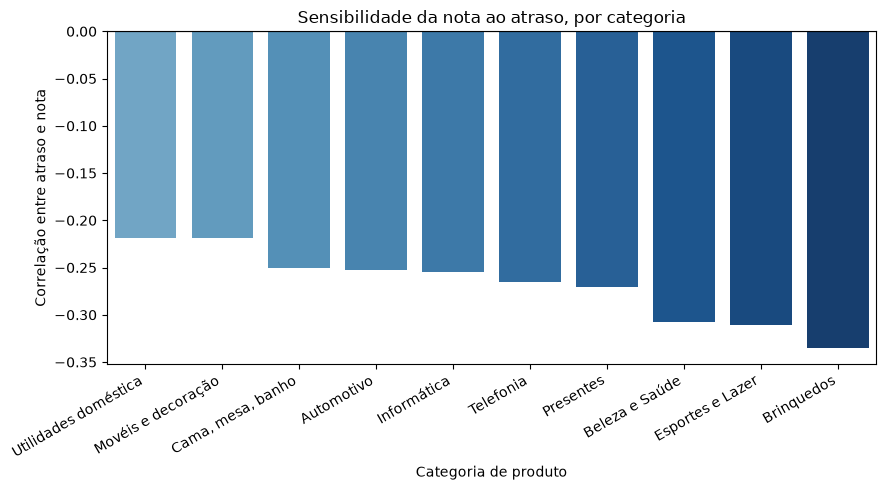

In [107]:
color_gradient= sns.color_palette("Blues", 20).as_hex()[10:20]

plt.figure(figsize=(9, 5))
sns.barplot(x=corr_categorias.index, y=corr_categorias.values, hue=corr_categorias.index, palette=color_gradient, legend=False)
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=30, ha="right")
plt.xlabel("Categoria de produto")
plt.ylabel("Correlação entre atraso e nota")
plt.title("Sensibilidade da nota ao atraso, por categoria")
plt.tight_layout()
plt.show()

Podemos investigar mais ainda se categoria faz uma diferença plotando um gráfico da média de notas por faixa de atraso de cada categoria.

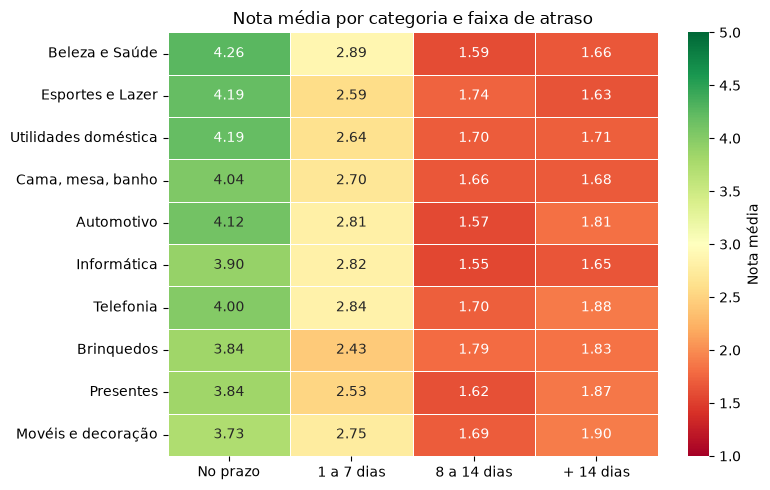

In [111]:
# Faixa de atraso limpa: 0 = no prazo (referência), depois só atrasos de verdade
faixas_pos = [0, 1, 8, 15, np.inf]
labels_pos = ["No prazo", "1 a 7 dias", "8 a 14 dias", "+ 14 dias"]
df_delivered["faixa_pos"] = pd.cut(df_delivered["atraso_num"], bins=faixas_pos,
                                   labels=labels_pos, right=False)

top10 = df_delivered.loc[df_delivered["product_category_name"].isin(categorias_renamed)]

matriz = top10.pivot_table(index="product_category_name", columns="faixa_pos",
                           values="review_score", aggfunc="mean", observed=True)
contagem = top10.pivot_table(index="product_category_name", columns="faixa_pos",
                             values="review_score", aggfunc="size", observed=True)

# Ordena pela maior queda entre "No prazo" e "+ 14 dias"
matriz = matriz.loc[(matriz["No prazo"] - matriz["+ 14 dias"]).sort_values(ascending=False).index]
contagem = contagem.loc[matriz.index]

plt.figure(figsize=(8, 5))
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="RdYlGn", vmin=1, vmax=5,
            cbar_kws={"label": "Nota média"}, linewidths=0.5)
plt.title("Nota média por categoria e faixa de atraso")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()